## Лабораторная работа №1
### Предварительный статистический анализ данных
#### Анализ распределений выборок на основе графиков и статистических тестов
##### Задачи исследования

1. Исследовать основные описательные статистики для каждого коэффициента (минимум, максимум, среднее, медиана, стандартное отклонение) с целью ознакомления с особенностями данных и их распределением.
2. Провести графический анализ данных с целью анализа их распределения на
основе построения гистограмм.
---

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import pyreadstat
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import shapiro, kstest, chisquare, norm

data_path = 'Annual 2005-2011_START.sav'
data, meta = pyreadstat.read_sav(data_path)

display(data.head())

stats = data.describe()
stats.loc['skew'] = data.skew(numeric_only=True)
stats.loc['kurt'] = data.kurt(numeric_only=True)
display(stats.iloc[:, 0:12])
display(stats.iloc[:, 12:23])

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,k9,k10,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
0,6095.0,0.942380,0.060563,0.678302,-0.161531,NaN,0.202055,0.165019,0.399033,0.799019,5.426569,0.209235,1.115922,1.082798,0.655937,4.454819,3.975687,0.892446,1007.536232,0.076738,0.055049,0.034904,5.0
1,255.0,1.980494,0.274382,0.916775,0.624425,NaN,0.089377,0.220648,0.000000,0.933519,14.041958,0.215083,1.259382,1.123828,0.705951,10.618881,12.295547,1.157895,357.294118,0.116068,0.059740,0.025647,5.0
2,114.0,0.374160,0.001494,0.085138,-1.504990,NaN,0.235739,0.508929,0.888889,0.779049,5.017007,0.096737,0.774586,1.185374,0.123415,0.794785,6.258929,7.875000,36.894737,-0.584879,0.010563,0.000000,5.0
3,365.0,7.859079,0.831978,2.449864,0.875862,NaN,0.059439,0.030030,0.011111,0.942010,16.244444,0.876663,1.223284,1.309449,2.804607,48.363889,26.142643,0.540541,33.676983,0.171731,0.496295,0.312415,5.0
4,168.0,1.779376,0.005596,0.883293,0.527853,NaN,0.135491,0.886686,0.489796,0.887341,10.558673,0.313389,0.874381,0.994832,0.473041,5.628827,3.125354,0.555241,19.103896,0.064809,0.025726,0.011839,5.0


,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,k9,k10
count,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,1540.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,1220.773284,2.002089,0.238018,0.825098,0.038115,0.335777,0.346330,0.238031,0.174212,0.655964,6.862756,0.831359
std,2556.406482,1.690052,0.517697,0.918292,0.625155,0.360196,0.198008,0.213094,0.223266,0.195774,7.943256,0.802107
min,10.000000,0.248322,0.000000,0.008329,-4.569874,-2.599123,0.009944,0.000000,0.000000,0.053766,0.059320,0.040014
25%,229.500000,1.097990,0.017088,0.317674,-0.181377,0.154884,0.185165,0.062932,0.001073,0.522272,2.590124,0.356280
50%,473.000000,1.473859,0.055551,0.538349,0.148620,0.367201,0.319908,0.185185,0.075676,0.681890,4.758963,0.617689
75%,1128.500000,2.238232,0.211538,0.941372,0.422199,0.573384,0.479741,0.361182,0.268773,0.817227,8.245208,0.987389
max,28650.000000,18.020148,7.029135,11.187699,0.935935,0.944507,1.083702,1.000000,1.000000,0.990056,199.605839,11.834268
skew,5.516686,3.385204,4.990825,3.428045,-2.322777,-1.778910,0.561709,1.008406,1.507845,-0.525526,7.700774,3.833633
kurt,39.396740,16.580257,35.883102,17.473216,9.356913,8.247683,-0.265989,0.449773,1.645573,-0.378203,141.337159,27.620585


,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,1.325512,1.351127,1.201444,9.944428,13.504512,2.149889,201.286497,0.054974,0.079206,0.065179,8.000000
std,0.537772,0.596442,0.700291,7.636115,13.384226,2.817287,2260.459197,0.110704,0.094002,0.146802,2.000371
min,0.098838,0.230067,0.033180,0.220451,0.347459,0.000000,0.447730,-0.975133,-0.321271,-2.670820,5.000000
25%,1.110017,1.071357,0.672567,4.598417,5.980288,0.734275,10.060489,0.023797,0.017260,0.004226,6.000000
50%,1.237491,1.180362,1.106136,8.169934,9.851228,1.235572,20.099094,0.059466,0.056022,0.044154,8.000000
75%,1.448376,1.356088,1.591163,13.316773,16.690873,2.384732,48.951216,0.103877,0.123064,0.119201,10.000000
max,15.865194,10.809042,4.982852,68.830441,195.041667,31.559748,104151.000000,0.860892,0.635036,0.836596,11.000000
skew,11.443269,4.716121,0.935870,1.874910,4.796901,4.266697,37.327021,-2.693214,1.234058,-4.211790,0.000000
kurt,265.654879,42.161859,1.175882,6.139569,42.230892,26.381324,1668.916385,19.759284,3.253020,68.574551,-1.250093


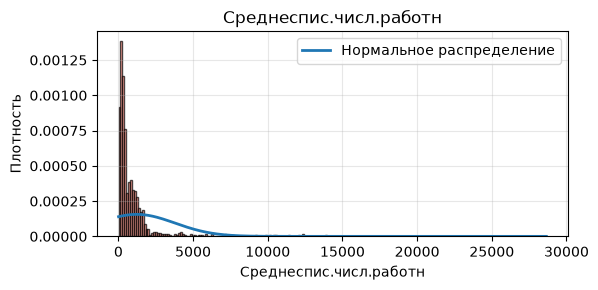

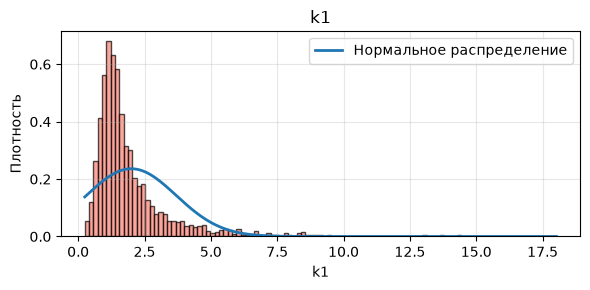

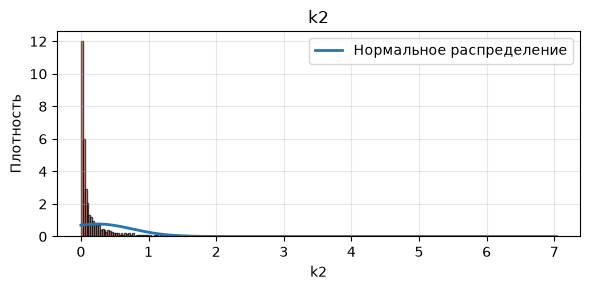

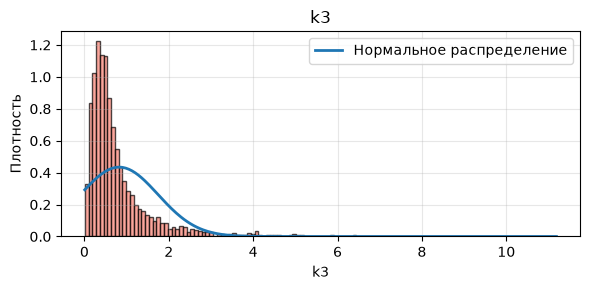

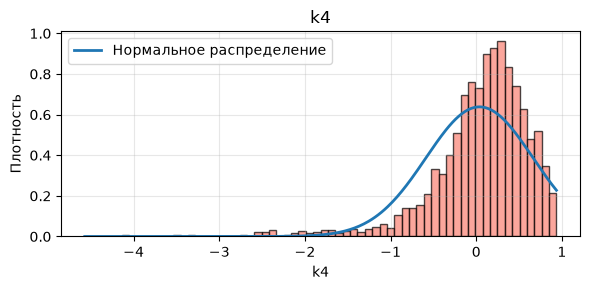

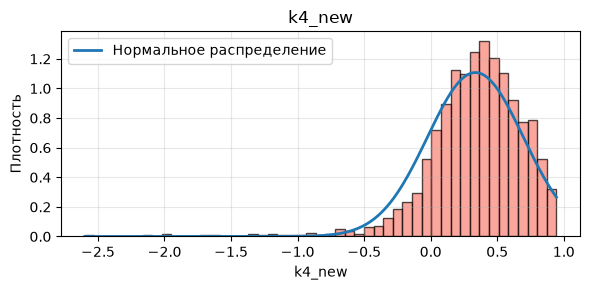

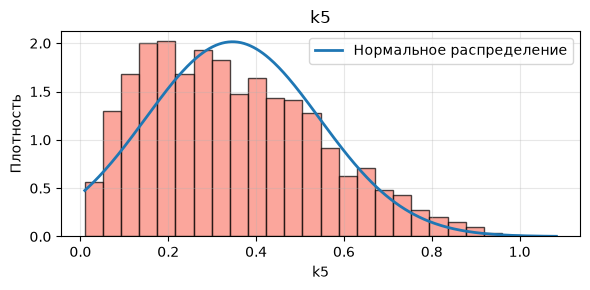

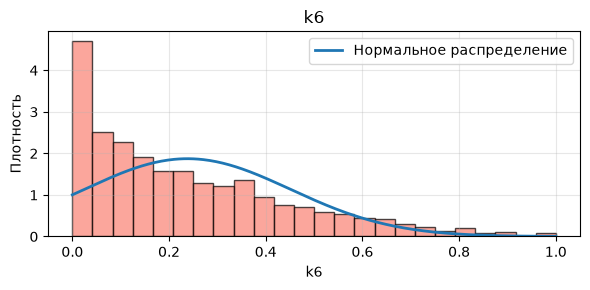

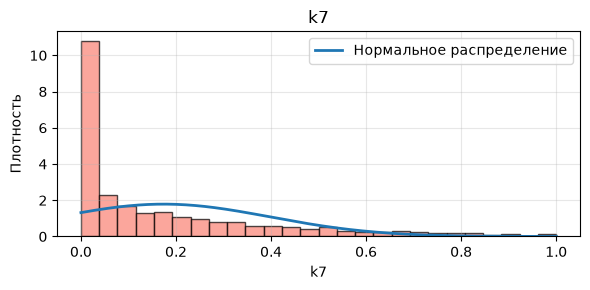

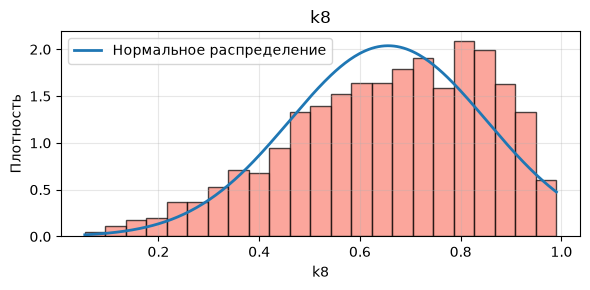

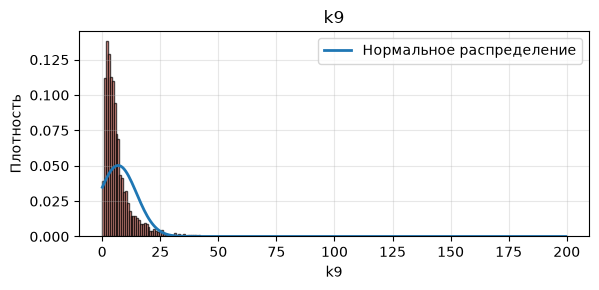

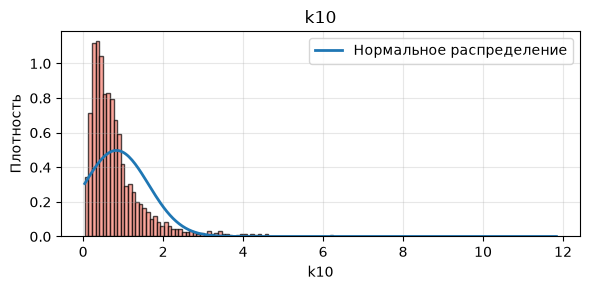

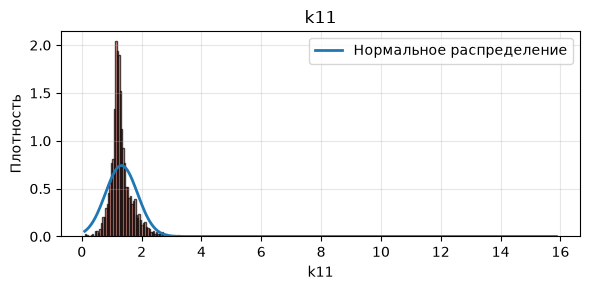

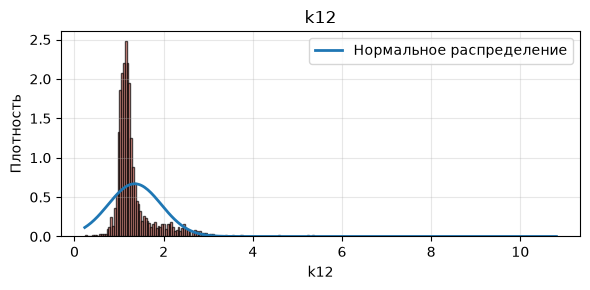

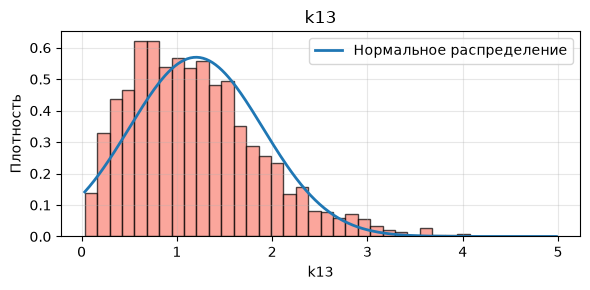

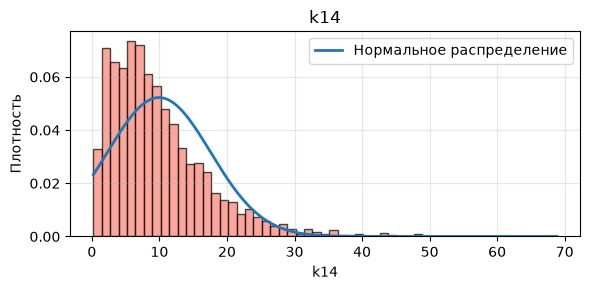

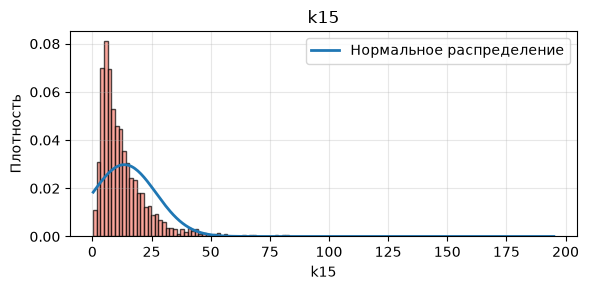

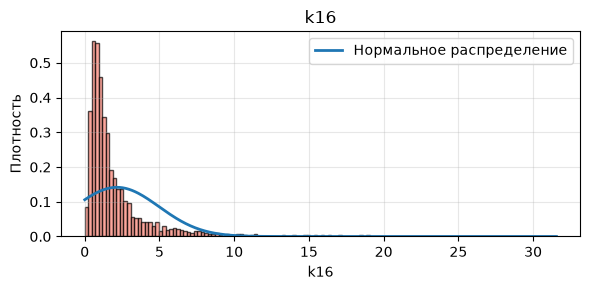

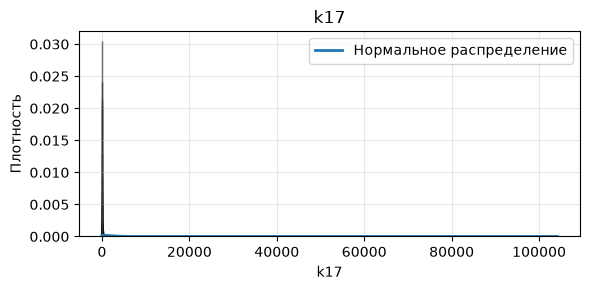

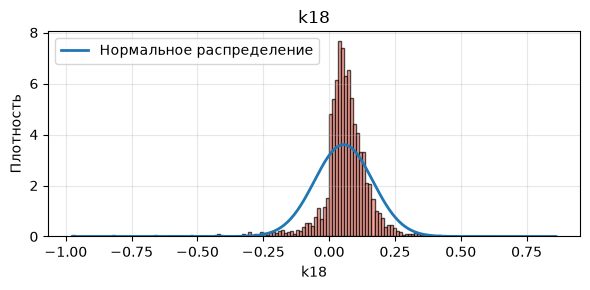

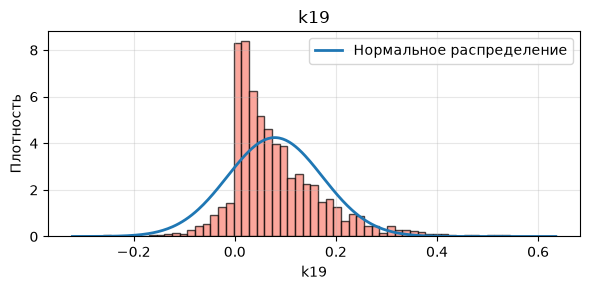

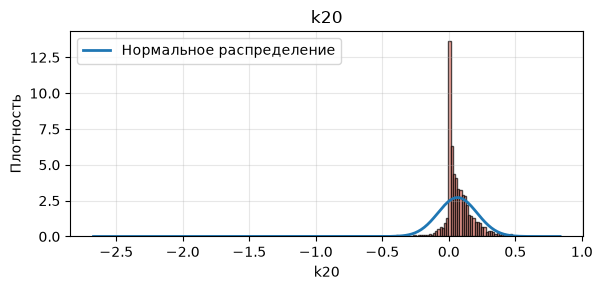

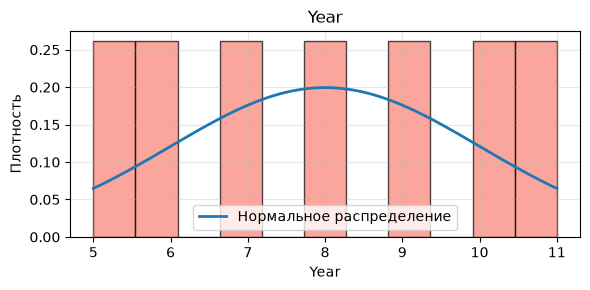

In [30]:
columns = data.select_dtypes(include = ['number']).columns

for column in columns:
    x = data[column].dropna()

    plt.figure(figsize = (6, 3))
    plt.hist(x, bins = 'fd', density = True, color = 'salmon',edgecolor = 'black', alpha = 0.7)

    x_normal = np.linspace(x.min(), x.max(), 300)
    y_normal = norm.pdf(x_normal, loc = x.mean(), scale = x.std())

    plt.plot(x_normal, y_normal, linewidth = 2, label = 'Нормальное распределение')

    plt.title(column)
    plt.xlabel(column)
    plt.ylabel('Плотность')
    plt.grid(True, alpha = 0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()

Выбор количества корзин основан на правиле Фридмана–Диакониса. Если посмотреть на числовые храктеристики, то можно заметить значительную ассиметрию и сделать предположение о большом количестве выбросов. Правило, которое мы используем основоно на межквартильном размахе и устойчиво к выбросам.

Ширина интервала = 2 * IQR * n^(−1/3)

1. Выводы относительно области значений анализируемых коэффициентов:
    - Область значений существенно различается
    - Часть ограничена от 0 до 1 **(k6, k7, k8)**
    - Часть имеет и отрицательные значения **(k4, k4_new, k18, k19, k20)**
    - Коэффиценты отличаются диапазоном (**Среднеспис.числ.работн** от 0 до 30000, а **k20** например от -2 до 1)
2. Выводы относительно разброса значений для отдельных коэффициентов:
    - Разброс также довольно неоднороден
    - **Среднеспис.числ.работн**(*2556.406482*) и **k17**(*2260.459197*) имеют наибольшее стандартное отклонение. Также слегка выделяются **k9**(*7.943256*), **k14**(*7.636115*) и **k15**(*13.384226*)
    - Наименьший разброс у **k19**(*0.094002*)
3. Выводы относительно близости средних значений и медиан рассматриваемых коэффициентов:
    - Правосторонняя ассиметрия (*mean > median*) замечена у большинства коэффицентов. Больше всего у **k17**(*201.286497 > 20.099094*)
    - Левосторонняя ассиметрия (*mean < median*) замечена **k4, k4_new, k8 и k18**
    - Наиболее симметричны **Year, k5 и k6**
4. Выводы относительно свойств распределения коэффициентов, в частности относительно нормальности распределения:
    - Гипотеза о нормальности отвергается для большинства коэффицентов
    - Большинство коэффицентов сильно скошены
    - **Year** имеет равномерное распределение
    - Больше всего визуально близки к нормальному распределению **k18, k19 и k20**
5. Выводы относительно наличия в выборках аномальных и экстремальных наблюдений:
    - Аномальные наблюдения присутствуют почти у всех коэффицентов
    - Наибольшие правосторонние выбросы у **k14, k15 и k17**
    - Наибольшие левосторонние выбросы у **k4_new, k18 и k20**

#### Анализ аномальных наблюдений
##### Задачи исследования
1. Исследовать возможность применения ящичных диаграмм, теста Хампеля и правила шести сигм для анализа экстремальных аномальных наблюдений в исследуемых данных. Проанализировать влияние ассиметричности распределений на результаты анализа
2. Осуществить коррекцию границ интервалов для указанных тестов с учетом экономической интерпретации результатов анализа.
---

1. Исследование возможности применения тестов и влияние асимметрии:
    - Метод построения ящичных диаграмм проблематичен, так как у многих коэффицентов длинные хвосты и большая ассиметрия. Из-за этого много большое количество верных данных может быть отмечено как выбросы
    - Тест Хампеля хорошо применим. Он является устойчивым к выброс, так как опирается на медиану и медиану абсолютных отклонений
    - Правило шести сигм не подходит, так как этот тест предпологает нормальность распределения. У нас же на нормальные похожи лишь пара коэффицентов из 23

2. Осуществить коррекцию границ интервалов для указанных тестов с учетом
экономической интерпретации результатов анализа
    - В следующей части задания будем применять тест Хампеля и там подкорректируем значение

##### Задачи исследования
3. Провести графический анализ данных с целью выявления аномальных наблюдений на основе построения ящичных диаграмм.
4. На основании условия ниже или «правила шести сигм» определить экстремальные наблюдения в выборке. Множитель в условии ниже подобрать таким образом, чтобы экстремальными признавалось не более 5-8% наблюдений
5. Провести цензурирование и нормировку данных.
$$[x_{med} - 5.2 \cdot x_{mad}, \; x_{med} + 5.2 \cdot x_{mad}]$$
---

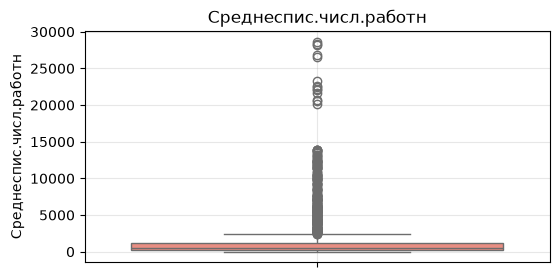

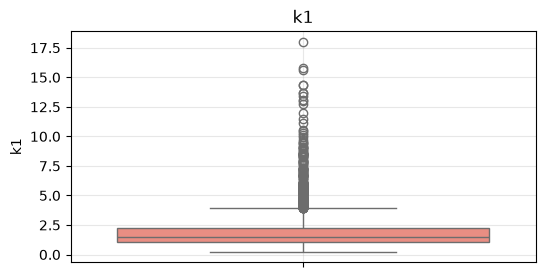

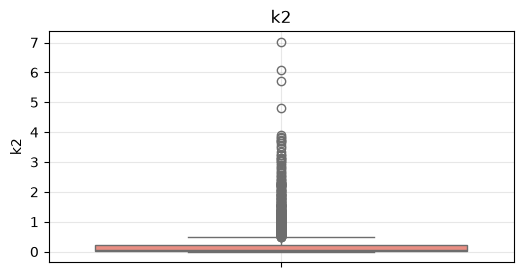

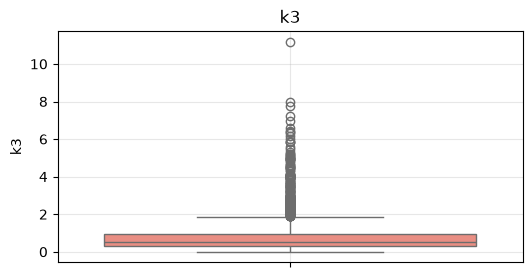

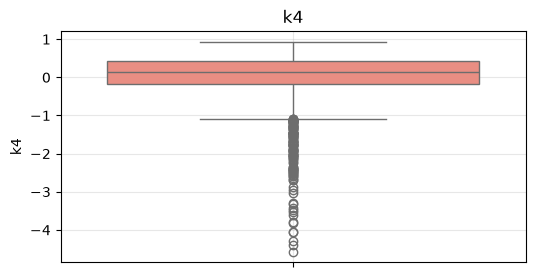

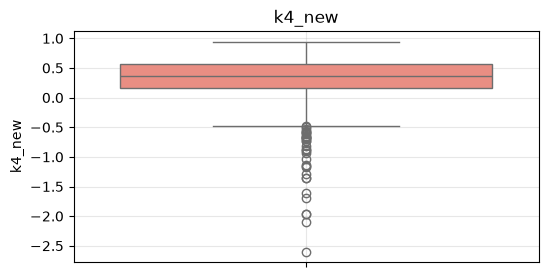

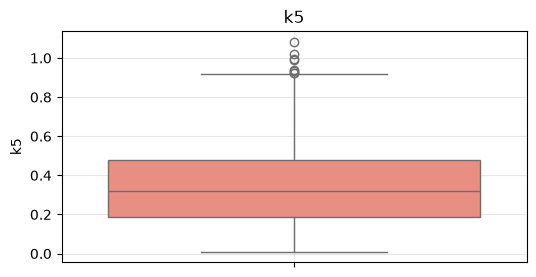

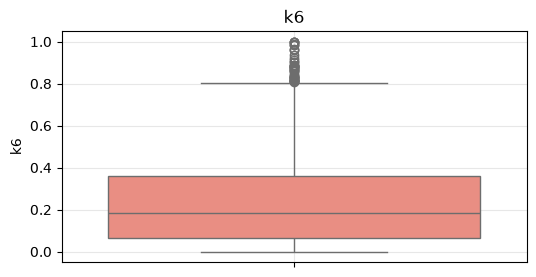

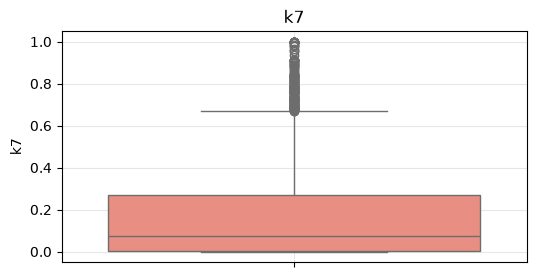

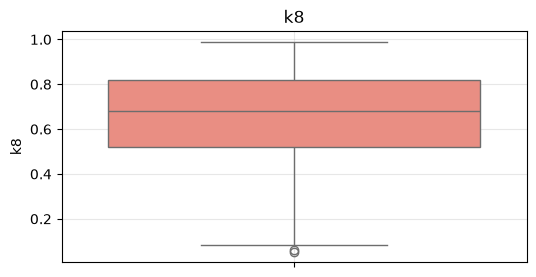

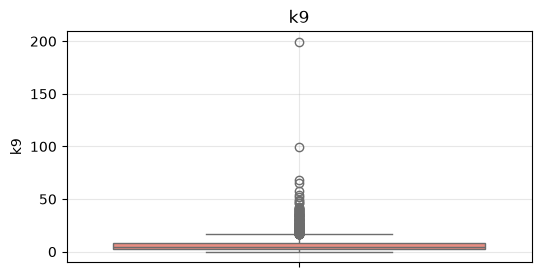

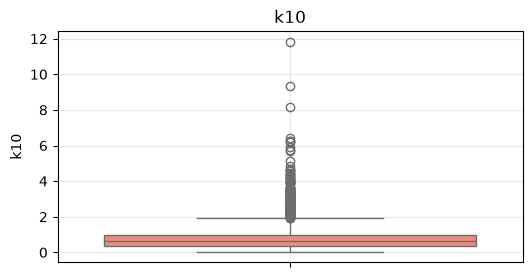

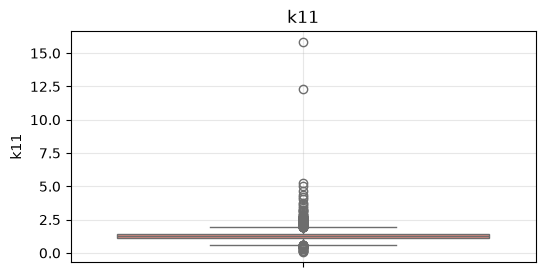

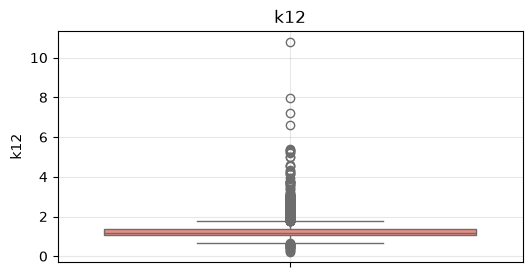

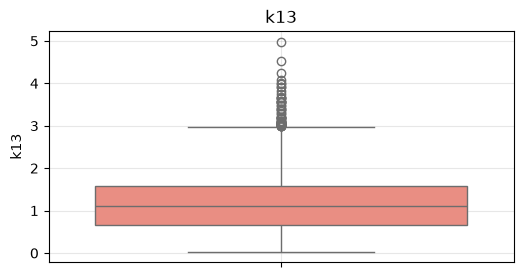

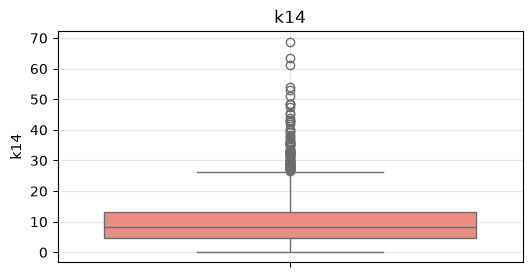

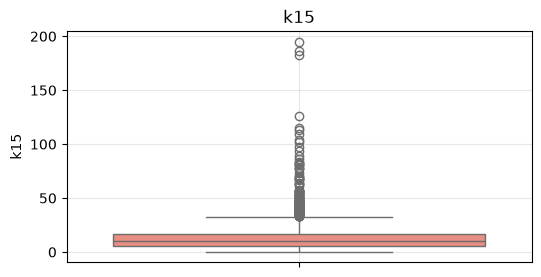

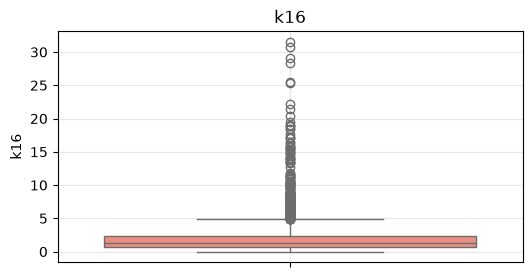

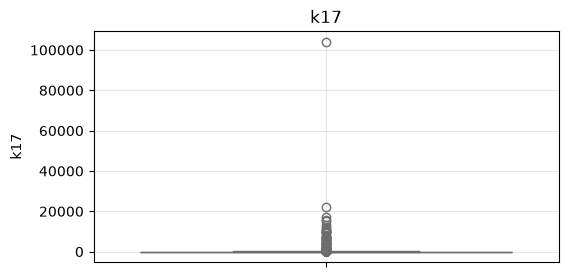

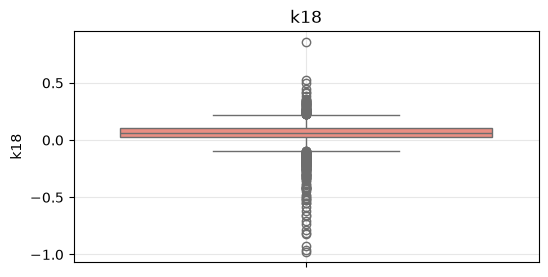

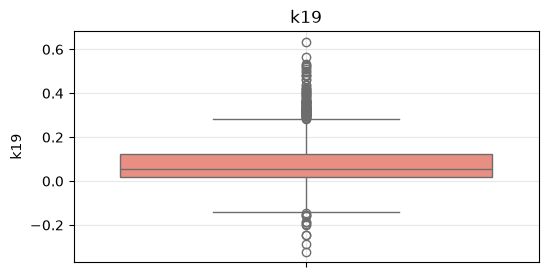

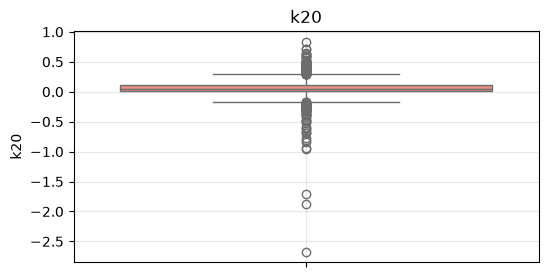

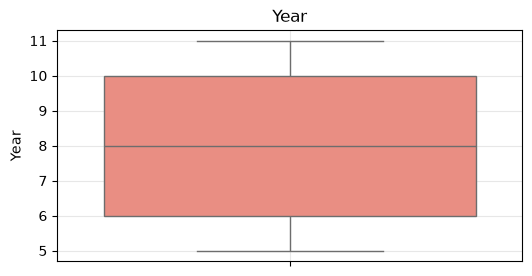

In [22]:
columns = data.select_dtypes(include = ['number']).columns

for column in columns:
    plt.figure(figsize = (6, 3))
    sns.boxplot(y = data[column], color = 'salmon')
    plt.title(column)
    plt.grid(True, alpha = 0.3)
    plt.show()

Построенные ящичные диагрммы показали, что для большинства характеристик характерна правая ассиметрия. Также замечено большое количество выбросов и сжатость самого ящика.

In [23]:
def select_hampel_k(series, min_percent = 5, max_percent = 8):
    x = series.dropna()
    med = x.median()
    mad = (x - med).abs().median()

    if len(x) == 0 or mad == 0:
        return np.nan, 0

    distances = ((x - med).abs() / mad).to_numpy()
    candidates = np.unique(distances)

    for k in candidates:
        percent = (distances > k).mean() * 100

        if min_percent <= percent <= max_percent:
            return float(k), float(percent)

    return np.nan, 0

def hampel_filter(data, k = 5.2):
    clean_data = data.dropna()
    med = clean_data.median()
    mad = (clean_data - med).abs().median()
    lower_bound = med - k * mad
    upper_bound = med + k * mad

    return lower_bound, upper_bound

In [24]:
data_censored = data.copy()
columns = data_censored.select_dtypes(include=['number']).columns
hampel_results = []

for column in columns:
    k, percent = select_hampel_k(data[column])

    if np.isnan(k):
        hampel_results.append([column, np.nan, np.nan, np.nan, 0, 0])
        continue

    lower_bound, upper_bound = hampel_filter(data[column], k)
    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)
    outliers_count = outliers.sum()
    valid_count = data[column].notna().sum()
    outliers_percent = outliers_count / valid_count * 100

    data_censored[column] = data[column].clip(lower_bound, upper_bound)
    hampel_results.append([column, k, lower_bound, upper_bound, outliers_count, outliers_percent])

hampel_results = pd.DataFrame(hampel_results, columns=['Показатель', 'k', 'Нижняя граница', 'Верхняя граница', 'Количество экстремальных', 'Доля экстремальных, %'])

display(hampel_results)

,Показатель,k,Нижняя граница,Верхняя граница,Количество экстремальных,"Доля экстремальных, %"
0,Cреднеспис.числ.работн,7.559375,-1946.000000,2892.000000,215,7.977737
1,k1,5.692883,-1.285310,4.233028,215,7.977737
2,k2,14.634024,-0.653603,0.764706,215,7.977737
3,k3,5.386129,-0.891326,1.968023,215,7.977737
4,k4,2.930560,-0.733660,1.030899,215,7.977737
5,k4_new,2.494193,-0.156918,0.891320,123,7.987013
6,k5,2.331614,-0.018740,0.658555,215,7.977737
7,k6,2.875040,-0.222122,0.592492,215,7.977737
8,k7,6.375078,-0.406763,0.558114,215,7.977737
9,k8,2.297502,0.349265,1.014515,215,7.977737


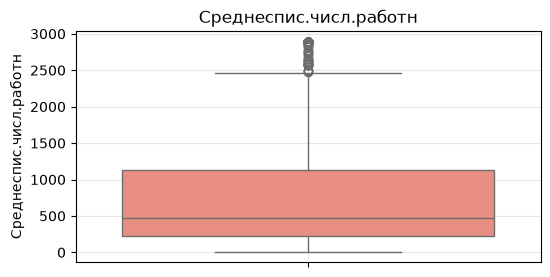

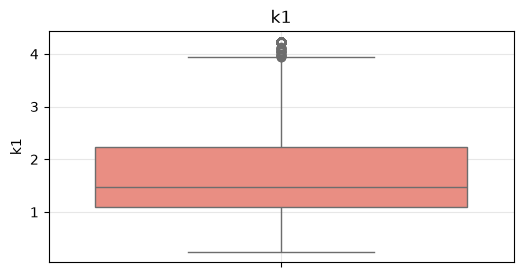

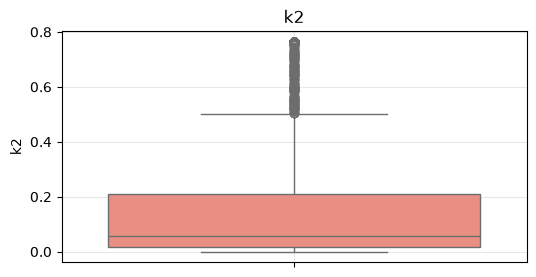

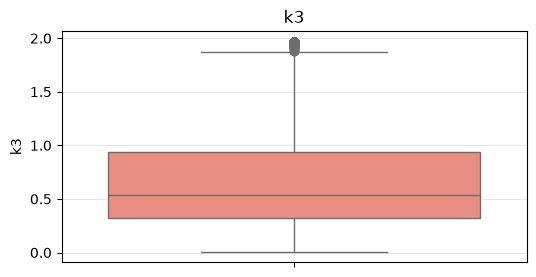

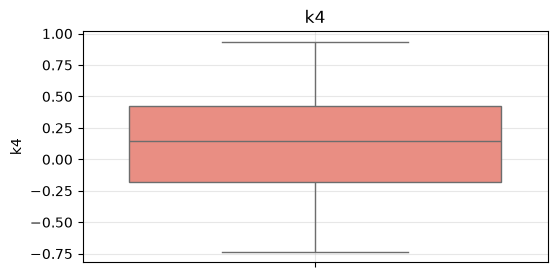

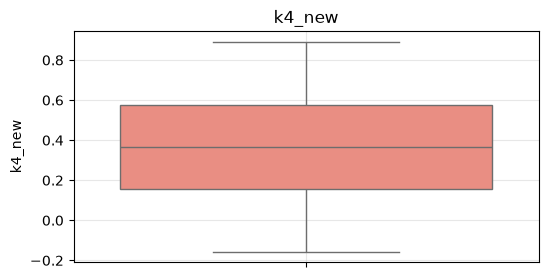

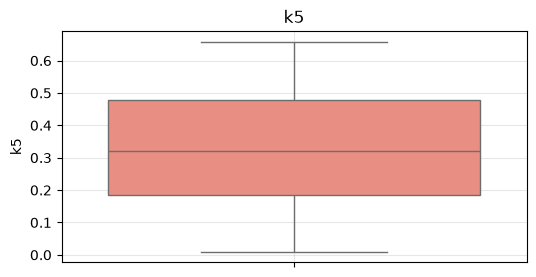

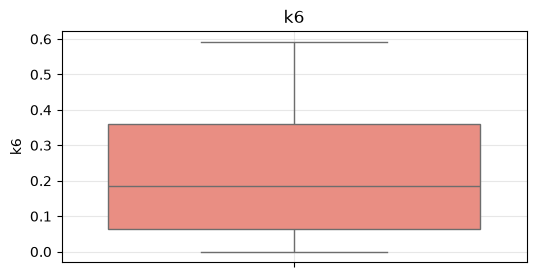

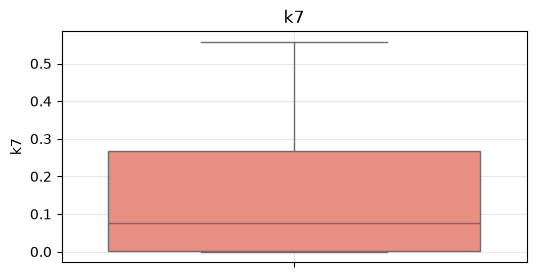

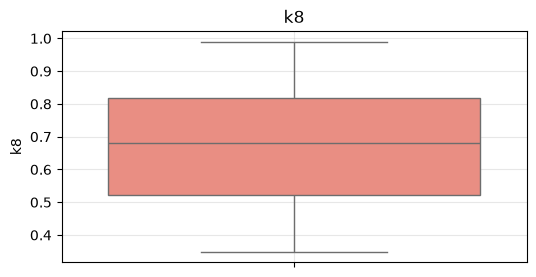

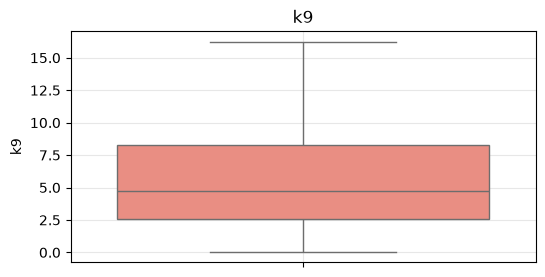

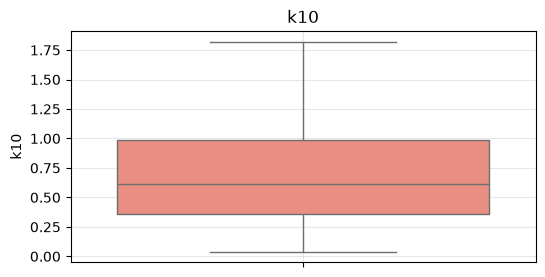

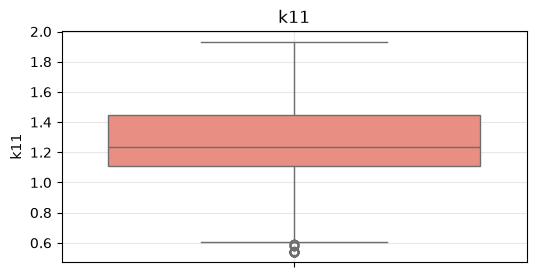

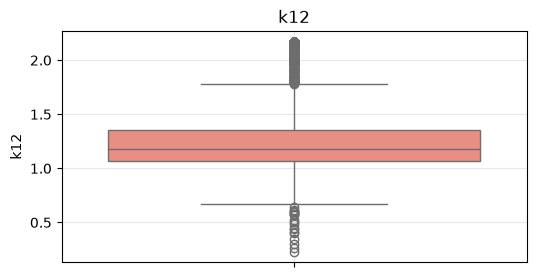

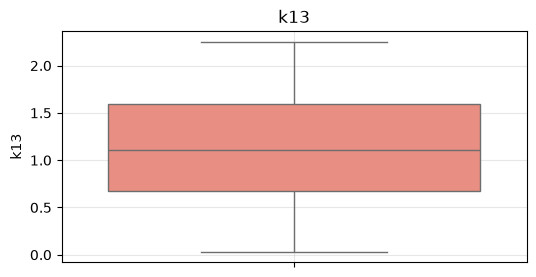

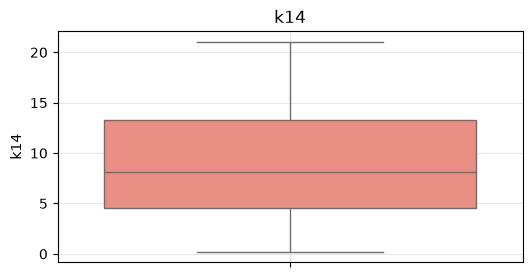

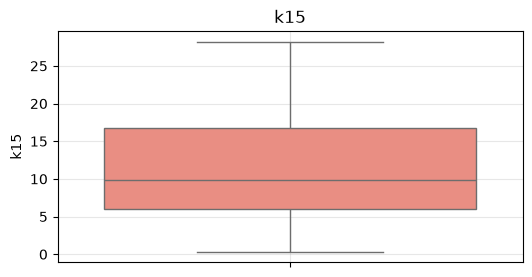

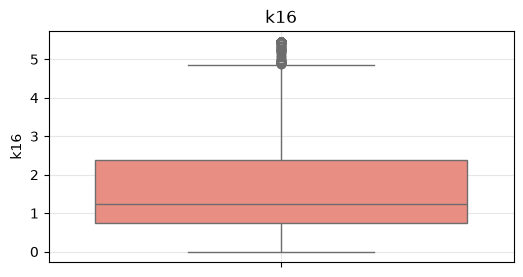

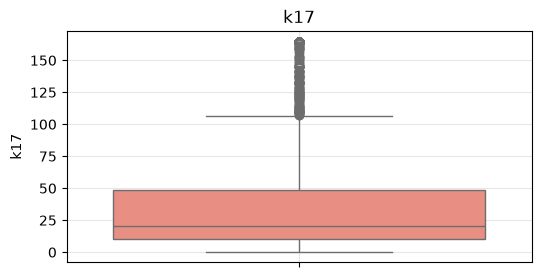

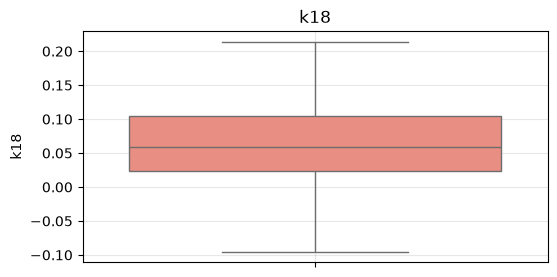

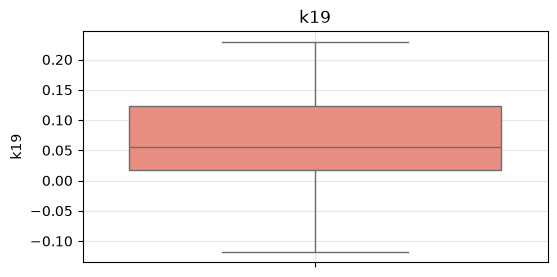

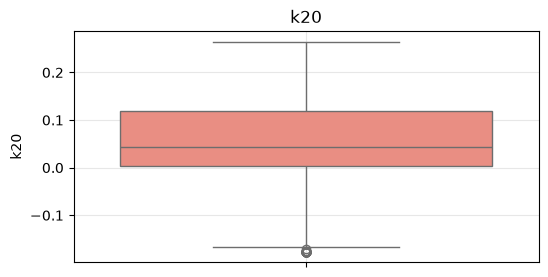

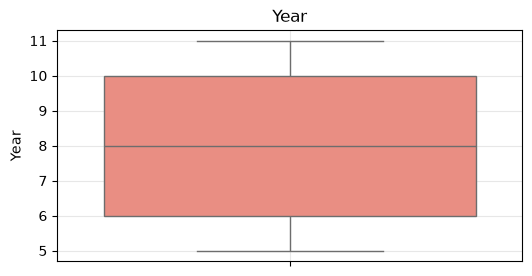

In [25]:
columns = data_censored.select_dtypes(include = ['number']).columns

for column in columns:
    plt.figure(figsize = (6, 3))
    sns.boxplot(y = data_censored[column], color = 'salmon')
    plt.title(column)
    plt.grid(True, alpha = 0.3)
    plt.show()

После цензурирования ящичные диаграммы улучшились

In [26]:
data_scaled = data_censored.copy()
columns = data_scaled.select_dtypes(include = ['number']).columns
scaler = StandardScaler()
data_scaled[columns] = scaler.fit_transform(data_scaled[columns])

stats = data_scaled.describe()
stats.loc['skew'] = data_scaled.skew(numeric_only=True)
stats.loc['kurt'] = data_scaled.kurt(numeric_only=True)
display(stats.iloc[:, 0:12])
display(stats.iloc[:, 12:23])

,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,k9,k10
count,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,1.540000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03
mean,-5.273044e-18,1.687374e-16,1.054609e-17,-1.054609e-17,1.581913e-17,-1.268826e-16,-3.691131e-17,1.581913e-17,-5.273044e-18,-7.909567e-17,7.909567e-17,-2.109218e-17
std,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000325e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00
min,-9.890383e-01,-1.514988e+00,-7.229413e-01,-1.302312e+00,-1.910963e+00,-1.815584e+00,-1.807868e+00,-1.204330e+00,-8.550839e-01,-1.744963e+00,-1.326864e+00,-1.423460e+00
25%,-7.174125e-01,-6.945850e-01,-6.495237e-01,-7.345434e-01,-6.445053e-01,-7.202794e-01,-8.440549e-01,-8.714401e-01,-8.493475e-01,-7.844947e-01,-7.702122e-01,-7.860862e-01
50%,-4.160873e-01,-3.316620e-01,-4.842637e-01,-3.295175e-01,1.122227e-01,2.555008e-02,-1.028935e-01,-2.247600e-01,-4.504024e-01,1.016432e-01,-2.931753e-01,-2.592677e-01
75%,3.950776e-01,4.063834e-01,1.859320e-01,4.101881e-01,7.395763e-01,7.498349e-01,7.762836e-01,7.062078e-01,5.822014e-01,8.529819e-01,4.736257e-01,4.857886e-01
max,2.577365e+00,2.332474e+00,2.562626e+00,2.294498e+00,1.917643e+00,1.866684e+00,1.759861e+00,1.929763e+00,2.129474e+00,1.812461e+00,2.233061e+00,2.166090e+00
skew,1.466510e+00,1.125725e+00,1.645225e+00,1.114319e+00,-3.259237e-01,-9.025557e-02,2.354748e-01,5.957216e-01,1.007150e+00,-2.189432e-01,1.009682e+00,8.793463e-01
kurt,1.218082e+00,3.211832e-01,1.401429e+00,1.997333e-01,-6.846162e-01,-8.362295e-01,-1.032028e+00,-8.641348e-01,-3.479783e-01,-1.044535e+00,-1.626333e-02,-2.329832e-01


,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
count,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2.695000e+03,2695.000000
mean,4.218436e-17,3.374748e-16,-8.964176e-17,-5.273044e-17,-4.218436e-17,-2.214679e-16,1.080974e-16,-2.109218e-17,1.370992e-16,1.370992e-16,0.000000
std,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186e+00,1.000186
min,-2.396163e+00,-2.909617e+00,-1.867625e+00,-1.539763e+00,-1.517512e+00,-1.192735e+00,-8.534752e-01,-2.270520e+00,-2.482293e+00,-2.573496e+00,-1.500000
25%,-5.762005e-01,-6.091626e-01,-8.084470e-01,-8.015927e-01,-7.879936e-01,-7.108525e-01,-6.510921e-01,-5.531098e-01,-7.337208e-01,-6.544135e-01,-1.000000
50%,-1.677934e-01,-3.110944e-01,-9.021755e-02,-1.993981e-01,-2.866611e-01,-3.818662e-01,-4.397434e-01,-3.814664e-02,-2.309647e-01,-2.302028e-01,0.000000
75%,5.078532e-01,1.694176e-01,7.132543e-01,6.684122e-01,5.991540e-01,3.722929e-01,1.676974e-01,6.030390e-01,6.385975e-01,5.671158e-01,1.000000
max,2.060576e+00,2.399332e+00,1.810148e+00,1.973667e+00,2.092223e+00,2.389905e+00,2.602140e+00,2.194227e+00,2.020363e+00,2.113090e+00,1.500000
skew,3.889253e-01,1.263636e+00,2.726536e-01,5.717677e-01,7.972825e-01,1.287889e+00,1.669930e+00,-1.257450e-01,4.691624e-01,2.888532e-01,0.000000
kurt,-6.622198e-02,9.160132e-01,-9.249482e-01,-7.076064e-01,-4.537010e-01,5.494629e-01,1.573965e+00,2.226461e-01,-3.075673e-01,2.970481e-01,-1.250093


Для применения тестов на нормальность необходимо:
- Колмогоров-Смирнов: количественные данные, непрерывное распределение, независимость данных
- Шапиро-Уилк: количественные данные, без пропусков, непрерывное распределение, независимость
- Хи-квадрат: независимость, непересекаемость интервалов, поппадание всех значений в выбранный интервал

In [27]:
from scipy.stats import shapiro, kstest, chisquare, norm

normality = pd.DataFrame(index = ['Шапиро-Уилк', 'Колмогоров-Смирнов', 'Хи-квадрат'])

for column in columns:
    x = data_censored[column].dropna()

    shapiro_p = shapiro(x).pvalue

    mean = x.mean()
    std = x.std()
    ks_p = kstest(x, norm(loc = mean, scale = std).cdf).pvalue

    borders = norm.ppf(np.linspace(0, 1, 14), loc = mean, scale = std)
    observed, _ = np.histogram(x, bins = borders)
    expected = np.full(13, len(x) / 13)

    chi_p = chisquare(observed, expected, ddof = 2).pvalue

    normality[column] = [shapiro_p, ks_p, chi_p]

pd.set_option('display.max_columns', None)
display(normality.style.format('{:.10f}'))



,Cреднеспис.числ.работн,k1,k2,k3,k4,k4_new,k5,k6,k7,k8,k9,k10,k11,k12,k13,k14,k15,k16,k17,k18,k19,k20,Year
Шапиро-Уилк,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000
Колмогоров-Смирнов,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000007858,0.0472428222,0.0000000008,0.0000000000,0.0000000000,0.0000000004,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000032,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000057,0.0000000000,0.0000000000,0.0000000000
Хи-квадрат,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0016221583,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000


После масштабирования у коэффцентов дисперсия и срденее стали 1 и 0

## Корреляционный анализ
#### Задачи исследования
1. Получить матрицу парных коэффициентов корреляции для всех имеющихся
показателей.
2. Выявить переменные, имеющие наиболее тесные взаимосвязи, а также
проанализировать знаки показателей корреляции.
3. Выделить переменные, которые возможно исключить из дальнейшего анализа в
силу существования тесной связи с другой/ими переменной/ыми

Для построения корреляционной матрицы Спирмена должны быть выполнены следующие условия:
1. Между признаками можно установить монотонную зависимость
2. Не требуется нормальность распределения
3. Наблюдения должны быть независимыми

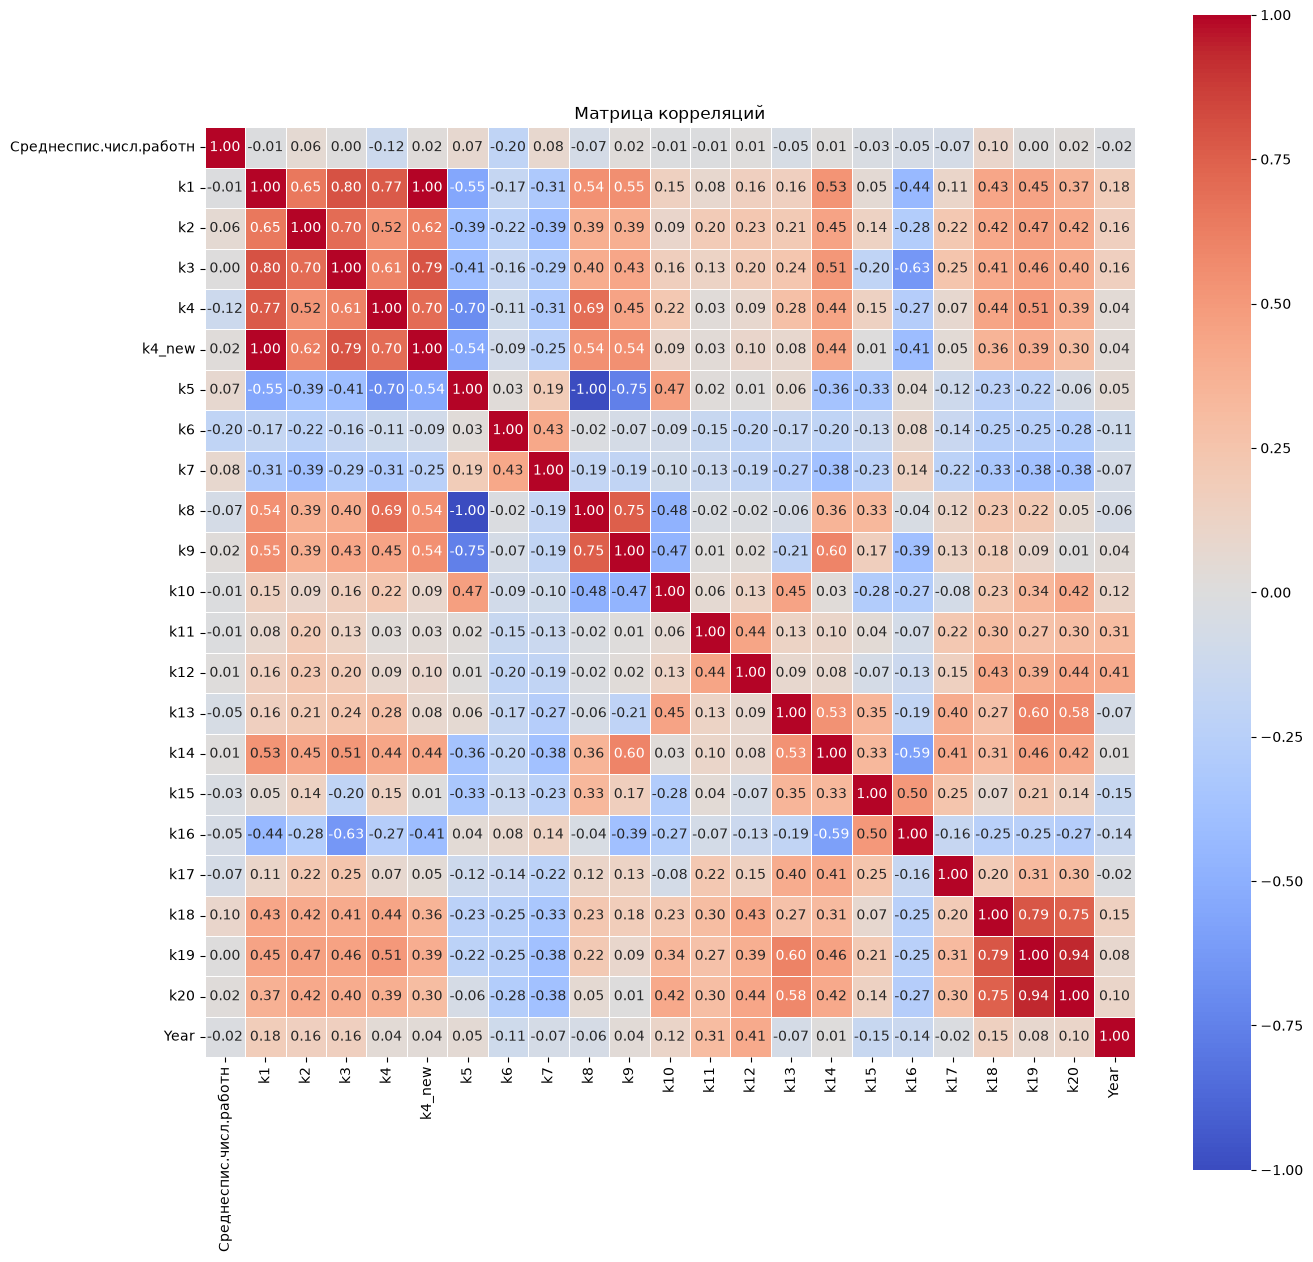

In [28]:
plt.figure(figsize = (15, 15))
sns.heatmap(data_censored.corr(method = 'spearman'), annot = True, fmt = '.2f', vmin = -1, vmax = 1, square = True, linewidths = 0.5, cmap = 'coolwarm')
plt.title('Матрица корреляций')
plt.show()

Выводы по матрице корреляций:
- Сильная положительная корреляция у **k1, k2, k3, k4, k4_new**, а также у **k18, k19 и k20**
- Сильная отрицательная корреляция у **k5, k8**
- Практически отсутствует связь у **Среднеспис.числ.работн** со всеми переменными и у **Year**